In [ ]:
# Section 1: Import Libraries
import kagglehub
import os
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.utils import plot_model
from skimage import exposure
from skimage.filters import gaussian, sobel
from scipy.ndimage import convolve

In [ ]:

# Section 2: Download and Prepare Dataset
# Download dataset
xhlulu_140k_real_and_fake_faces_path = kagglehub.dataset_download('xhlulu/140k-real-and-fake-faces')
print('Data source import complete.')

100%|██████████| 3.75G/3.75G [00:43<00:00, 93.1MB/s]

Extracting files...


Data source import complete.


In [ ]:
# Move dataset to new path
import shutil

new_path = "/content/Dataset"
if not os.path.exists(new_path):
    os.makedirs(new_path)
# Use shutil.move to move the contents of the source directory to the destination directory.
# This will work even if the destination directory exists and is not empty.
shutil.move(xhlulu_140k_real_and_fake_faces_path, new_path)
print("Dataset moved to:", new_path)

Dataset moved to: /content/Dataset


In [ ]:
# Define directories
train_dir = '/content/Dataset/2/real_vs_fake/real-vs-fake/train'
val_dir = '/content/Dataset/2/real_vs_fake/real-vs-fake/valid'
test_dir = '/content/Dataset/2/real_vs_fake/real-vs-fake/test'

In [ ]:
print("Train_dir Subfolders:", os.listdir(train_dir))
print("Valid_dir Subfolders:", os.listdir(val_dir))
print("Test_dir Subfolders:", os.listdir(test_dir))

Train_dir Subfolders: ['real', 'fake']
Valid_dir Subfolders: ['real', 'fake']
Test_dir Subfolders: ['real', 'fake']


In [ ]:
# Section 3: Define Image Enhancement Functions
# Define a kernel for sharpening
sharpening_kernel = np.array([[0, -1, 0],
                              [-1, 5, -1],
                              [0, -1, 0]])

# Function to apply kernel filtering to each channel of the image
def apply_kernel_filter(img):
    # Apply the kernel to each channel separately
    filtered_channels = []
    for channel in range(img.shape[-1]):  # Loop through each channel (e.g., R, G, B)
        filtered_channel = convolve(img[:, :, channel], sharpening_kernel, mode='reflect')
        filtered_channels.append(filtered_channel)

    # Stack the filtered channels back into a single image
    filtered_img = np.stack(filtered_channels, axis=-1)
    return filtered_img

# Function to apply histogram equalization
def apply_histogram_equalization(img):
    return exposure.equalize_hist(img)

# Function to enhance an image
def enhance_image(img):
    img = apply_kernel_filter(img)  # Apply sharpening
    img = apply_histogram_equalization(img)  # Apply histogram equalization
    return img

/usr/local/lib/python3.11/dist-packages/skimage/_shared/utils.py:445: UserWarning: This might be a color image. The histogram will be computed on the flattened image. You can instead apply this function to each color channel, or set channel_axis.
  return func(*args, **kwargs)


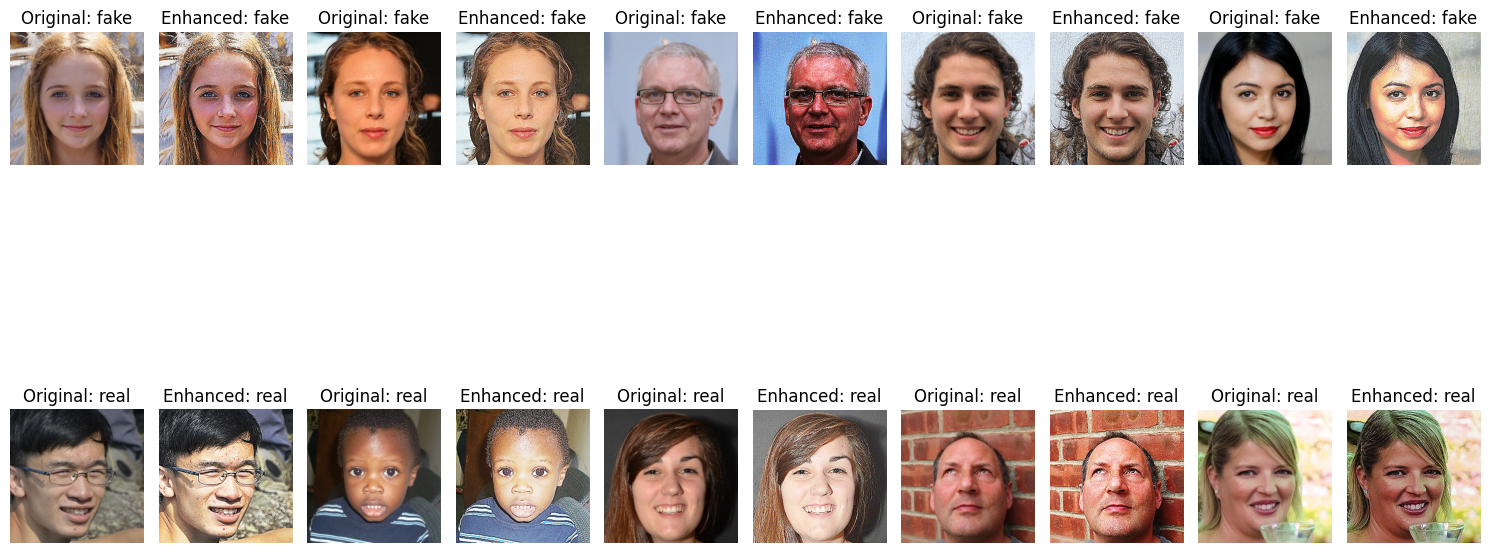

In [ ]:
# Section 4: Visualize Original and Enhanced Images
# Define class names
class_names = ['fake', 'real']
num_images = 5  # Number of images to display

# Plot original and enhanced images
plt.figure(figsize=(15, 10))
for i, class_name in enumerate(class_names):
    class_dir = os.path.join(train_dir, class_name)
    images = os.listdir(class_dir)
    selected_images = random.sample(images, num_images)  # Randomly select images

    for j, img_name in enumerate(selected_images):
        img_path = os.path.join(class_dir, img_name)
        img = mpimg.imread(img_path) / 255.0  # Normalize image

        # Plot original image
        plt.subplot(len(class_names), num_images * 2, i * (num_images * 2) + 2 * j + 1)
        plt.imshow(img)
        plt.title(f'Original: {class_name}')
        plt.axis('off')

        # Enhance image
        enhanced_img = enhance_image(img)

        # Plot enhanced image
        plt.subplot(len(class_names), num_images * 2, i * (num_images * 2) + 2 * j + 2)
        plt.imshow(enhanced_img)
        plt.title(f'Enhanced: {class_name}')
        plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Section 5: Apply Enhancements to Dataset
# Create directories for enhanced dataset
enhanced_train_dir = '/content/Dataset/enhanced_train'
enhanced_val_dir = '/content/Dataset/enhanced_val'
enhanced_test_dir = '/content/Dataset/enhanced_test'


In [ ]:
os.makedirs(enhanced_train_dir, exist_ok=True)
os.makedirs(enhanced_val_dir, exist_ok=True)
os.makedirs(enhanced_test_dir, exist_ok=True)

In [ ]:
# Function to enhance and save images
def enhance_and_save_dataset(original_dir, enhanced_dir):
    for class_name in class_names:
        class_dir = os.path.join(original_dir, class_name)
        enhanced_class_dir = os.path.join(enhanced_dir, class_name)
        os.makedirs(enhanced_class_dir, exist_ok=True)

        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            img = mpimg.imread(img_path) / 255.0  # Normalize image
            enhanced_img = enhance_image(img)  # Apply enhancement
            enhanced_img_path = os.path.join(enhanced_class_dir, img_name)
            plt.imsave(enhanced_img_path, enhanced_img)

# Apply enhancements to train, validation, and test datasets
enhance_and_save_dataset(train_dir, enhanced_train_dir)
enhance_and_save_dataset(val_dir, enhanced_val_dir)
enhance_and_save_dataset(test_dir, enhanced_test_dir)

print("Dataset enhancement complete.")

Dataset enhancement complete.


In [ ]:
# Section 6: Data Generators for Enhanced Dataset
# Image data generators for enhanced dataset
train_datagen = ImageDataGenerator(rescale=1./255)
val_test_datagen = ImageDataGenerator(rescale=1./255)
target_size = (256, 256)
batch_size = 64

train_generator = train_datagen.flow_from_directory(
    enhanced_train_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='binary'
)

val_generator = val_test_datagen.flow_from_directory(
    enhanced_val_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='binary'
)

test_generator = val_test_datagen.flow_from_directory(
    enhanced_test_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

print("Training class distribution:", train_generator.class_indices)
print("Validation class distribution:", val_generator.class_indices)


Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Training class distribution: {'fake': 0, 'real': 1}
Validation class distribution: {'fake': 0, 'real': 1}


In [ ]:

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
model = models.Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(256, 256, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(256, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(256, activation='relu'),
    #Dropout(0.5),
    Dense(128, activation='relu'),
    #Dropout(0.5),
    Dense(64, activation='relu'),
    #Dropout(0.5),
    Dense(1, activation='sigmoid')  # Sigmoid for binary classification
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Callbacks
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)


In [ ]:
# Section 8: Train the Model
# Train the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stopping, reduce_lr]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 404s 250ms/step - accuracy: 0.6855 - loss: 0.5576 - val_accuracy: 0.9004 - val_loss: 0.2405 - learning_rate: 0.0010
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 334s 214ms/step - accuracy: 0.9187 - loss: 0.2024 - val_accuracy: 0.9338 - val_loss: 0.1724 - learning_rate: 0.0010
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 386s 247ms/step - accuracy: 0.9548 - loss: 0.1173 - val_accuracy: 0.9466 - val_loss: 0.1373 - learning_rate: 0.0010
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 338s 216ms/step - accuracy: 0.9704 - loss: 0.0778 - val_accuracy: 0.9575 - val_loss: 0.1111 - learning_rate: 0.0010
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 343s 219ms/step - accuracy: 0.9790 - loss: 0.0561 - val_accuracy: 0.9679 - val_loss: 0.0939 - learning_rate: 0.0010
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 336s 215ms/step - accuracy: 0.9828 - loss: 0.0464 - val_accuracy: 0.9693 - val_loss: 0.0903 - learning_rate: 0.0010
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 365s 233ms

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Save the model
model.save('/content/drive/MyDrive/DFDEmodel/Enhanced_deep_cnn_model.h5')

In [ ]:
# Section 9: Evaluate the Model
# Evaluate the model
test_metrics = model.evaluate(test_generator)
print("Test metrics:", test_metrics[1])

test_metrics = model.evaluate(train_generator)
print("Train metrics:", test_metrics[1])


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


313/313 ━━━━━━━━━━━━━━━━━━━━ 74s 237ms/step - accuracy: 0.9695 - loss: 0.0896
Test metrics: 0.9695500135421753
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 254s 162ms/step - accuracy: 0.9919 - loss: 0.0230
Train metrics: 0.9919099807739258


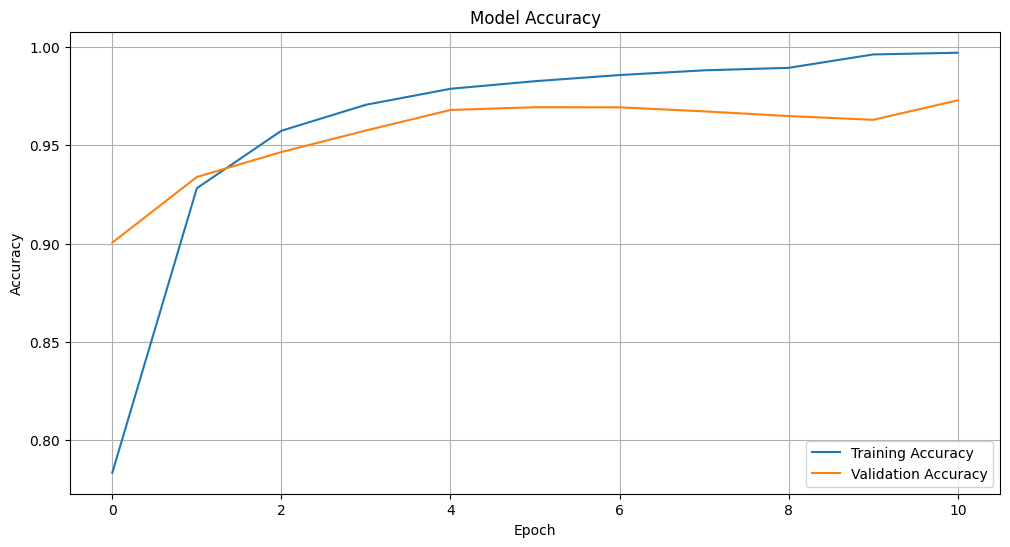

In [ ]:
# Plot accuracy
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.savefig("/content/drive/MyDrive/DFDEmodel/dfdeacc.png")
plt.grid(True)
plt.show()

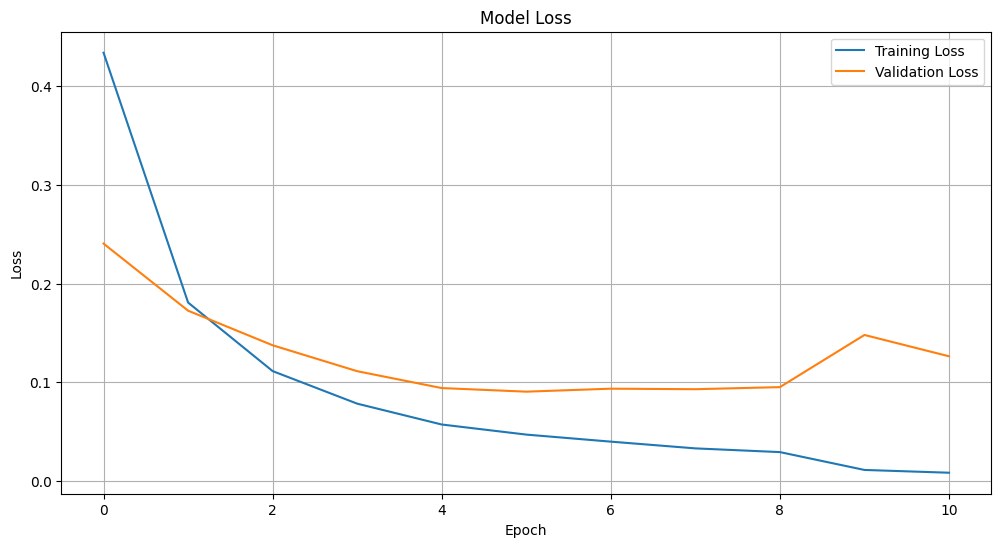

In [ ]:
# Plot loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.savefig("/content/drive/MyDrive/DFDEmodel/dfdeloss.png")
plt.grid(True)
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 50s 158ms/step
              precision    recall  f1-score   support

        fake       0.97      0.97      0.97     10000
        real       0.97      0.97      0.97     10000

    accuracy                           0.97     20000
   macro avg       0.97      0.97      0.97     20000
weighted avg       0.97      0.97      0.97     20000



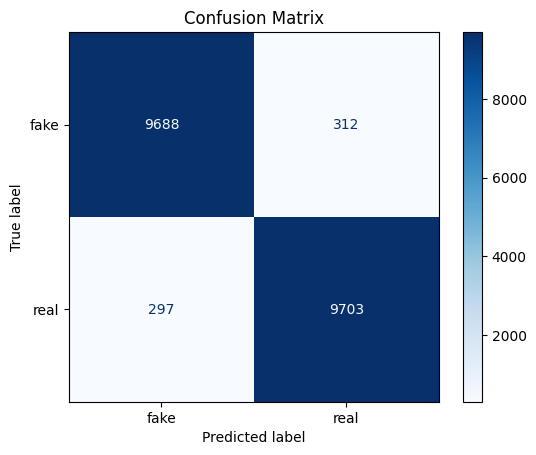

In [ ]:
# Section 10: Make Predictions and Confusion Matrix
# Make predictions
test_generator.reset()
predictions = model.predict(test_generator, verbose=1)
predicted_classes = np.where(predictions > 0.5, 1, 0)
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

cm = confusion_matrix(true_classes, predicted_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_generator.class_indices.keys())
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.savefig("/content/drive/MyDrive/DFDEmodel/dfdecm.png")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 935ms/step


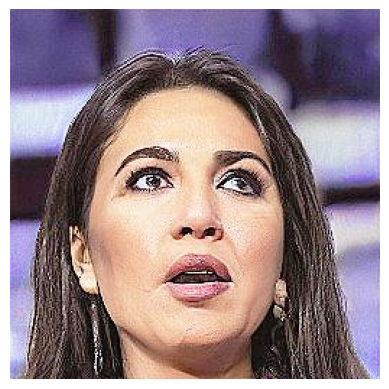

The model predicts this image is 'real' with a confidence of 0.21%.
The model predicts this image is 'fake' with a confidence of 99.79%.


In [ ]:
# Section 11: Test with a Single Image
# Function to load and preprocess the image
def load_and_preprocess_image(img_path, target_size):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img, img_array

# Test with an image
img_path = '/content/Dataset/enhanced_test/fake/009ZTJ3621.jpg'
img, img_array = load_and_preprocess_image(img_path, target_size)
prediction = model.predict(img_array)
real_confidence = prediction[0][0] * 100
fake_confidence = (1 - prediction[0][0]) * 100
plt.imshow(img)
plt.axis('off')
plt.show()
print(f"The model predicts this image is 'real' with a confidence of {real_confidence:.2f}%.")
print(f"The model predicts this image is 'fake' with a confidence of {fake_confidence:.2f}%.")

In [ ]:
# Section 12: Save Model Weights
# Save model weights
model.save_weights('/content/drive/MyDrive/DFDEmodel/dfdeweights.weights.h5')